# Mission #008 — AgriCo : prédiction du rendement agricole

Client (fictif) : AgriCo, coopérative agritech.

Double objectif :
1. Prédire le rendement attendu selon les conditions de culture.
2. Identifier les leviers actionnables (engrais, irrigation) les plus efficaces pour l'améliorer.

Distinction clé : on sépare les facteurs subis (météo, sol, culture) des facteurs actionnables(engrais, irrigation). Seuls les seconds donnent lieu à des recommandations concrètes pour l'agriculteur.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## 1. Chargement des données

In [2]:
# Adapter le chemin si necessaire
df = pd.read_csv("C:/Users/beruc/Downloads/crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


## 2. Exploration

In [10]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (1000000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [4]:
# Valeurs manquantes
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [5]:
# Statistiques de la cible (rendement)
df["Yield_tons_per_hectare"].describe()

count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

### Distributions des variables numeriques

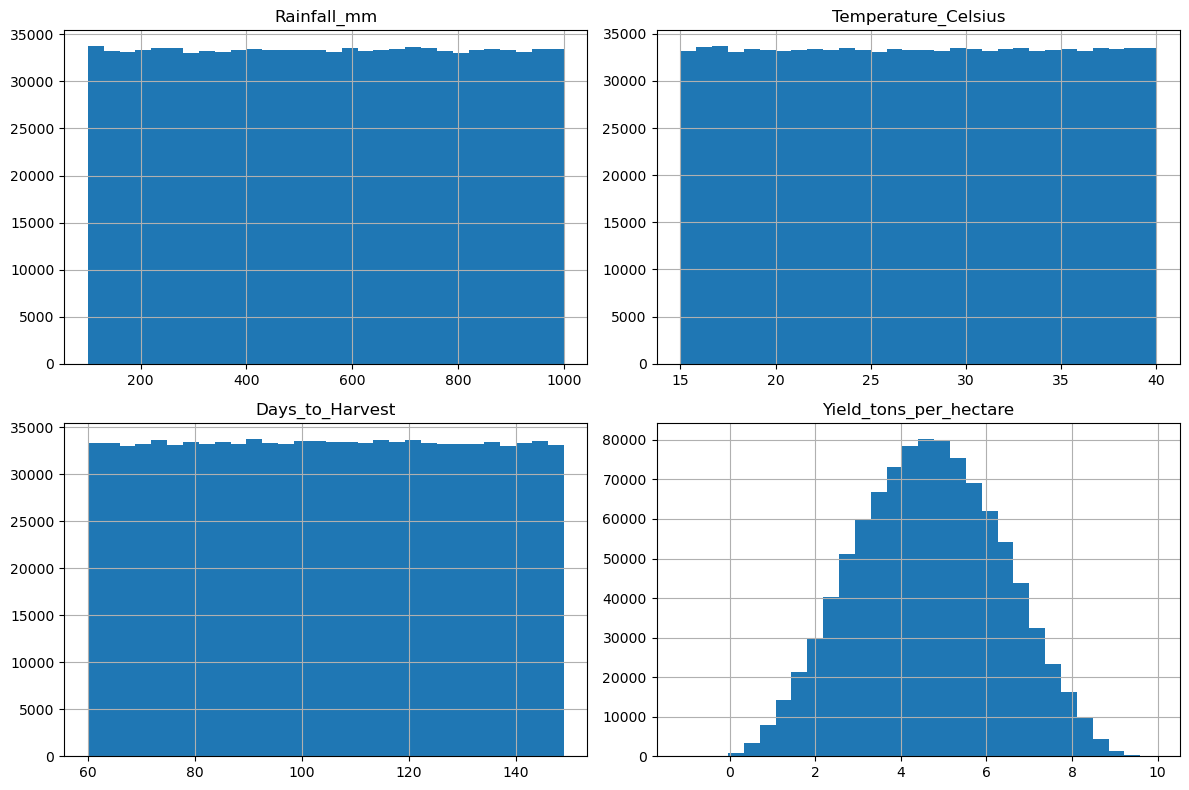

In [6]:
df.select_dtypes(include="number").hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

### Matrice de correlation


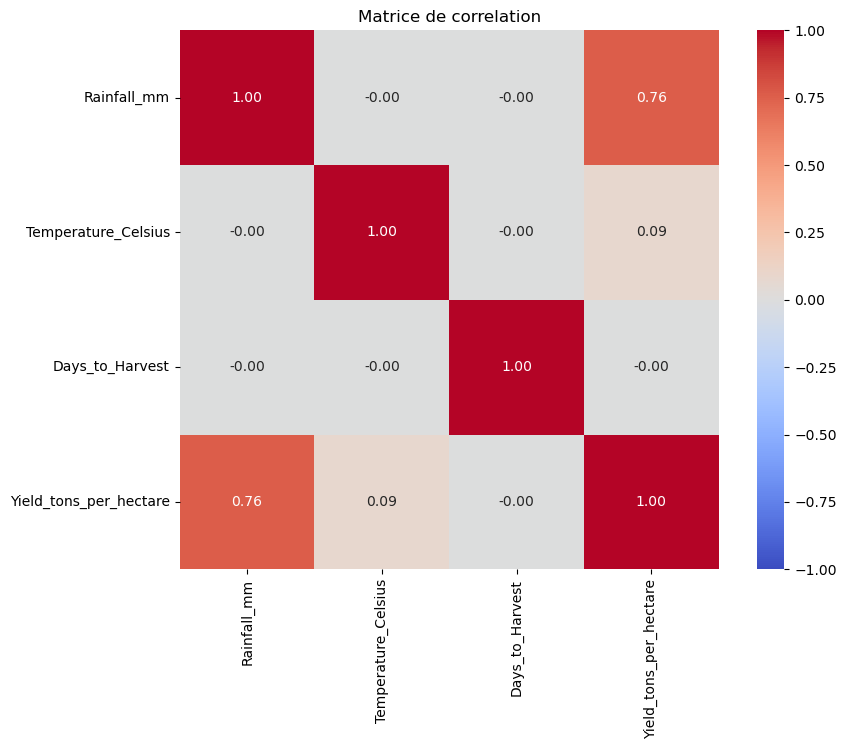

In [7]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True)
plt.title("Matrice de correlation")
plt.show()

### Effet des leviers actionnables

Les colonnes Fertilizer_Used et Irrigation_Used sont booleennes : on mesure ici leur effet direct sur le rendement moyen.

In [3]:
print("Rendement moyen selon l'engrais :")
print(df.groupby("Fertilizer_Used")["Yield_tons_per_hectare"].mean().round(2))

print("\nRendement moyen selon l'irrigation :")
print(df.groupby("Irrigation_Used")["Yield_tons_per_hectare"].mean().round(2))

print("\nCombinaison des deux leviers :")
print(df.groupby(["Fertilizer_Used", "Irrigation_Used"])["Yield_tons_per_hectare"].mean().round(2))

Rendement moyen selon l'engrais :
Fertilizer_Used
False    3.9
True     5.4
Name: Yield_tons_per_hectare, dtype: float64

Rendement moyen selon l'irrigation :
Irrigation_Used
False    4.05
True     5.25
Name: Yield_tons_per_hectare, dtype: float64

Combinaison des deux leviers :
Fertilizer_Used  Irrigation_Used
False            False              3.3
                 True               4.5
True             False              4.8
                 True               6.0
Name: Yield_tons_per_hectare, dtype: float64


## 3. Preparation des donnees

Fertilizer_Used et Irrigation_Used sont des booleens. select_dtypes ne les capte ni dans "object" ni dans "number" : sans conversion, ils seraient ignores par le modele. Or ce sont les leviers actionnables, au coeur de la mission. On les convertit donc en 0/1 pour qu'ils soient pris comme variables numeriques.

In [11]:
y = df["Yield_tons_per_hectare"]
x = df.drop(columns=["Yield_tons_per_hectare"])

# Conversion des leviers booleens en 0/1 (sinon ignores par le modele)
x["Fertilizer_Used"] = x["Fertilizer_Used"].astype(int)
x["Irrigation_Used"] = x["Irrigation_Used"].astype(int)

In [12]:
x_cate = x.select_dtypes(include="object").columns.tolist()
x_nume = x.select_dtypes(include="number").columns.tolist()
print("Categorielles :", x_cate)
print("Numeriques    :", x_nume)

Categorielles : ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
Numeriques    : ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest']


## 4. Pipeline de preprocessing

In [13]:
nume_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", cate_pipeline, x_cate),
    ("num", nume_pipeline, x_nume)
])

## 5. Entrainement et evaluation

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [15]:
def evaluation_model(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred = model.predict(x_test)
    print("R2 train :", round(r2_score(y_train, y_pred_train), 3))
    print("R2 test  :", round(r2_score(y_test, y_pred), 3))
    print("MAE train:", round(mean_absolute_error(y_train, y_pred_train), 2))
    print("MAE test :", round(mean_absolute_error(y_test, y_pred), 2))

### Regression lineaire

In [16]:
model_lr = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])
evaluation_model(model_lr, x_train, x_test, y_train, y_test)

R2 train : 0.913
R2 test  : 0.913
MAE train: 0.4
MAE test : 0.4


### Random Forest

In [9]:
model_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])
evaluation_model(model_rf, x_train, x_test, y_train, y_test)

R2 train : 0.987
R2 test  : 0.908
MAE train: 0.15
MAE test : 0.41


Modele retenu : la regression lineaire (R2  0,91, erreur  0,4 t/ha). Le Random Forest atteint un R2 comparable mais surapprend nettement (R2 train  0,99 contre  0,91 en test) et reste moins interpretable. Le rendement dependant des variables de facon largement lineaire, le modele simple est le meilleur choix.

## 6. Interpretation : facteurs subis vs leviers actionnables

Coefficients lus en unites reelles (regression sans standardisation). Les leviers etant codes 0/1, leur coefficient se lit directement comme le gain de rendement associe.

In [17]:
pre_interpret = ColumnTransformer(transformers=[
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))]), x_cate),
    ("num", SimpleImputer(strategy="median"), x_nume)
])

model_interpret = Pipeline([("pre", pre_interpret), ("lr", LinearRegression())])
model_interpret.fit(x_train, y_train)

noms = model_interpret.named_steps["pre"].get_feature_names_out()
coefs = model_interpret.named_steps["lr"].coef_

resultats = pd.DataFrame({"variable": noms, "coefficient": coefs.round(4)})
resultats = resultats.sort_values("coefficient", ascending=False)
print(resultats.to_string(index=False))
print("\nIntercept :", round(model_interpret.named_steps["lr"].intercept_, 2))

                    variable  coefficient
        num__Fertilizer_Used       1.4994
        num__Irrigation_Used       1.1992
    num__Temperature_Celsius       0.0199
            num__Rainfall_mm       0.0050
         cat__Soil_Type_Clay       0.0032
        cat__Soil_Type_Sandy       0.0027
              cat__Crop_Rice       0.0015
cat__Weather_Condition_Rainy       0.0015
           cat__Region_North       0.0005
         cat__Soil_Type_Loam       0.0002
        cat__Soil_Type_Peaty       0.0001
        num__Days_to_Harvest       0.0000
cat__Weather_Condition_Sunny      -0.0002
           cat__Region_South      -0.0005
           cat__Crop_Soybean      -0.0007
            cat__Region_West      -0.0007
            cat__Crop_Cotton      -0.0017
         cat__Soil_Type_Silt      -0.0017
             cat__Crop_Wheat      -0.0029
             cat__Crop_Maize      -0.0030

Intercept : 0.0


Lecture :
- Pluie (Rainfall_mm) : coefficient faible par mm (~0,005) mais domine par son amplitude (0 a 1000 mm). Facteur n°1, mais subi.
- Engrais (Fertilizer_Used): +1,5 t/ha. Levier actionnable le plus puissant.
- Irrigation (Irrigation_Used): +1,2 t/ha. Deuxieme levier.
- Sol, culture, region, condition meteo, duree : coefficients ~ 0, aucun effet notable.

## 7. Outil de prediction du rendement

Fonction qui prend les conditions d'une parcelle et les choix de l'agriculteur, et renvoie le rendement predit.

In [18]:
def predire_rendement(Region, Soil_Type, Crop, Rainfall_mm, Temperature_Celsius,
                      Fertilizer_Used, Irrigation_Used, Weather_Condition, Days_to_Harvest):
    # Predit le rendement (t/ha) a partir des conditions de culture et des choix
    parcelle = pd.DataFrame([{
        "Region": Region,
        "Soil_Type": Soil_Type,
        "Crop": Crop,
        "Rainfall_mm": Rainfall_mm,
        "Temperature_Celsius": Temperature_Celsius,
        "Fertilizer_Used": int(Fertilizer_Used),
        "Irrigation_Used": int(Irrigation_Used),
        "Weather_Condition": Weather_Condition,
        "Days_to_Harvest": Days_to_Harvest
    }])
    rendement = model_lr.predict(parcelle)[0]
    return round(rendement, 2)

In [19]:
# Demonstration : meme parcelle, avec et sans les leviers
base = dict(Region="North", Soil_Type="Loam", Crop="Wheat", Rainfall_mm=550,
            Temperature_Celsius=25, Weather_Condition="Sunny", Days_to_Harvest=120)

sans = predire_rendement(**base, Fertilizer_Used=False, Irrigation_Used=False)
avec = predire_rendement(**base, Fertilizer_Used=True,  Irrigation_Used=True)

print(f"Sans engrais ni irrigation : {sans} t/ha")
print(f"Avec engrais + irrigation  : {avec} t/ha")
print(f"Gain des leviers           : +{round(avec - sans, 2)} t/ha")

Sans engrais ni irrigation : 3.25 t/ha
Avec engrais + irrigation  : 5.95 t/ha
Gain des leviers           : +2.7 t/ha


## Conclusion

- Modele retenu : regression lineaire, R2 test  0,91, erreur moyenne  0,4 t/ha.
- Facteur dominant : la pluie (subie, non actionnable).
- Leviers actionnables : l'engrais (+1,5 t/ha) puis l'irrigation (+1,2 t/ha). Combines, ils font presque doubler le rendement (de 3,3 a 6,0 t/ha).
- Outil de prediction operationnel, capable de chiffrer le gain d'activation des leviers sur une parcelle donnee.

Limites : le type de sol, la culture, la region et la condition meteo n'ont aucun effet notable (contre-intuitif, signe de donnees en partie synthetiques) ; le jeu contient des rendements negatifs, physiquement impossibles. Resultats a interpreter comme un exercice methodologique.